# Tarefa: Pré-processamento das Marés de João Pessoa

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados
## Dataset — Tábua de Marés do Porto de Cabedelo (PB) · 2025

**Objetivo:** Aplicar normalização Min-Max, padronização Z-score e discretização por faixas em dados reais de altura de maré para identificar padrões de navegação e segurança. A variação das marés dita o ritmo de atividades turísticas como as visitas a Picãozinho e à Ilha de Areia Vermelha. Nesta atividade, simularemos o tratamento de dados brutos de uma estação oceanográfica real (DNPVN — Carta 830, 1 410 eventos, 365 dias).

### 1. Importações e Configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### 2. Carregamento e Exploração dos Dados

In [3]:
df = pd.read_csv('mareCabedelo.csv', parse_dates=['data'])
df['datetime'] = pd.to_datetime(df['data'].astype(str) + ' ' + df['hora'])

print('Primeiras observacoes do dataset:')
display(df.head(10))

print(f'\nDimensoes : {df.shape[0]} eventos x {df.shape[1]} colunas')
print(f'Periodo   : {df["data"].min().date()} a {df["data"].max().date()}')
print(f'Tipos de mare : {df["tipo_mare"].value_counts().to_dict()}')

Primeiras observacoes do dataset:


,data,dia_semana,hora,altura_m,tipo_mare,datetime
0,2025-01-01,Quarta-feira,05:16,2.13,Preamar,2025-01-01 05:16:00
1,2025-01-01,Quarta-feira,11:12,0.27,Baixa-mar,2025-01-01 11:12:00
2,2025-01-01,Quarta-feira,17:25,2.31,Preamar,2025-01-01 17:25:00
3,2025-01-01,Quarta-feira,23:42,0.10,Baixa-mar,2025-01-01 23:42:00
4,2025-01-17,Sexta-feira,00:21,0.20,Baixa-mar,2025-01-17 00:21:00
5,2025-01-17,Sexta-feira,06:36,2.07,Preamar,2025-01-17 06:36:00
6,2025-01-17,Sexta-feira,12:23,0.35,Baixa-mar,2025-01-17 12:23:00
7,2025-01-17,Sexta-feira,18:44,2.18,Preamar,2025-01-17 18:44:00
8,2025-01-02,Quinta-feira,05:57,2.14,Preamar,2025-01-02 05:57:00
9,2025-01-02,Quinta-feira,11:53,0.26,Baixa-mar,2025-01-02 11:53:00



Dimensoes : 1410 eventos x 6 colunas
Periodo   : 2025-01-01 a 2025-12-31
Tipos de mare : {'Preamar': 705, 'Baixa-mar': 705}


In [4]:
display(df[['altura_m']].describe().round(4))

,altura_m
count,1410.0000
mean,1.3340
std,0.8561
min,-0.0500
25%,0.5100
50%,1.3400
75%,2.1500
max,2.7800


### 3. Análise Exploratória — Distribuição Mensal das Marés

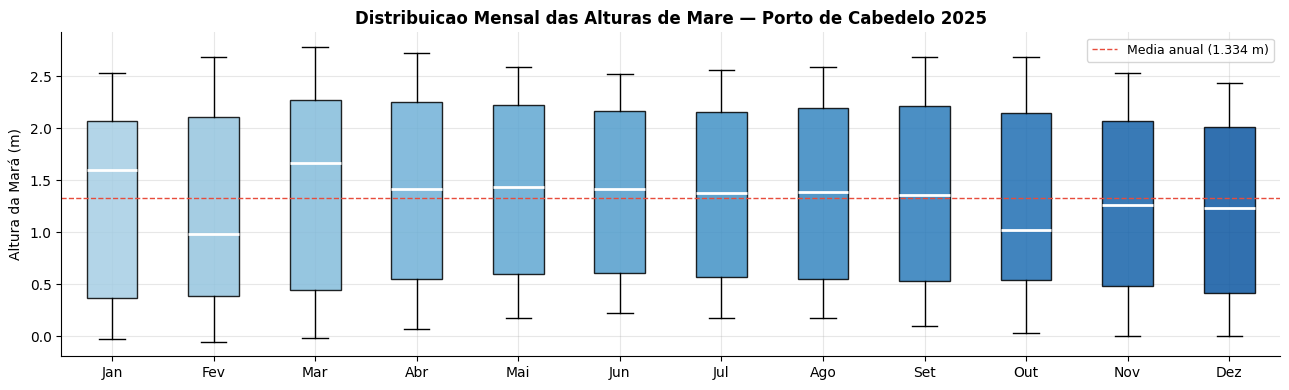

In [5]:
df['mes'] = df['data'].dt.month
df['mes_nome'] = df['data'].dt.strftime('%b')

fig, ax = plt.subplots(figsize=(13, 4))

meses = sorted(df['mes'].unique())
dados_box = [df[df['mes'] == m]['altura_m'].values for m in meses]
nomes_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

bp = ax.boxplot(dados_box, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

cores = plt.cm.Blues(np.linspace(0.35, 0.85, 12))
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

ax.set_xticklabels(nomes_meses, fontsize=10)
ax.set_ylabel('Altura da Mará (m)', fontsize=10)
ax.set_title('Distribuicao Mensal das Alturas de Mare — Porto de Cabedelo 2025',
             fontsize=12, fontweight='bold')
ax.axhline(1.334, color='#e74c3c', linestyle='--', linewidth=1, label=f'Media anual (1.334 m)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4. Pré-processamento — Normalização, Z-score e Discretização

Aplicamos três transformações sobre a coluna `altura_m`:

- **Normalização Min-Max** — escala os valores para [0, 1], onde 0 = mínimo histórico (−0.05 m) e 1 = máximo (2.78 m).
- **Z-score da altura** — em vez de pressão atmosférica (não disponível), usamos a própria amplitude da maré como indicador de anomalia: valores com |z| > 1.5 marcam marés excepcionalmente altas ou baixas.
- **Discretização por faixas** — converte a altura contínua em 5 categorias operacionais para decisão de navegação.

In [6]:
# ── a) Normalização Min-Max ──────────────────────────────────────────────────
h_min = df['altura_m'].min()   # -0.05 m (28/02/2025)
h_max = df['altura_m'].max()   #  2.78 m (29/03/2025)

df['mare_normalizada'] = (df['altura_m'] - h_min) / (h_max - h_min)

# ── b) Z-score (padronização) ─────────────────────────────────────────────────
h_mean = df['altura_m'].mean()  # 1.3340 m
h_std  = df['altura_m'].std()   # 0.8561 m

df['altura_zscore'] = (df['altura_m'] - h_mean) / h_std

# ── c) Discretização por faixas operacionais ──────────────────────────────────
bins   = [-np.inf, 0.5, 1.0, 1.6, 2.2, np.inf]
labels = ['Muito Baixa', 'Baixa', 'Media', 'Alta', 'Muito Alta']
df['categoria_mare'] = pd.cut(df['altura_m'], bins=bins, labels=labels)

print('Dados com transformacoes aplicadas (primeiras 12 linhas):')
display(df[['data','hora','tipo_mare','altura_m',
            'mare_normalizada','altura_zscore','categoria_mare']].head(12))

Dados com transformacoes aplicadas (primeiras 12 linhas):


,data,hora,tipo_mare,altura_m,mare_normalizada,altura_zscore,categoria_mare
0,2025-01-01,05:16,Preamar,2.13,0.770318,0.929858,Alta
1,2025-01-01,11:12,Baixa-mar,0.27,0.113074,-1.242887,Muito Baixa
2,2025-01-01,17:25,Preamar,2.31,0.833922,1.140123,Muito Alta
3,2025-01-01,23:42,Baixa-mar,0.10,0.053004,-1.441471,Muito Baixa
4,2025-01-17,00:21,Baixa-mar,0.20,0.088339,-1.324657,Muito Baixa
5,2025-01-17,06:36,Preamar,2.07,0.749117,0.859769,Alta
6,2025-01-17,12:23,Baixa-mar,0.35,0.141343,-1.149435,Muito Baixa
7,2025-01-17,18:44,Preamar,2.18,0.787986,0.988265,Alta
8,2025-01-02,05:57,Preamar,2.14,0.773852,0.941539,Alta
9,2025-01-02,11:53,Baixa-mar,0.26,0.109541,-1.254568,Muito Baixa


### 5. Visualizações dos Resultados

#### 5.1 Série Temporal — Altura Bruta × Normalizada (Janeiro/2025)

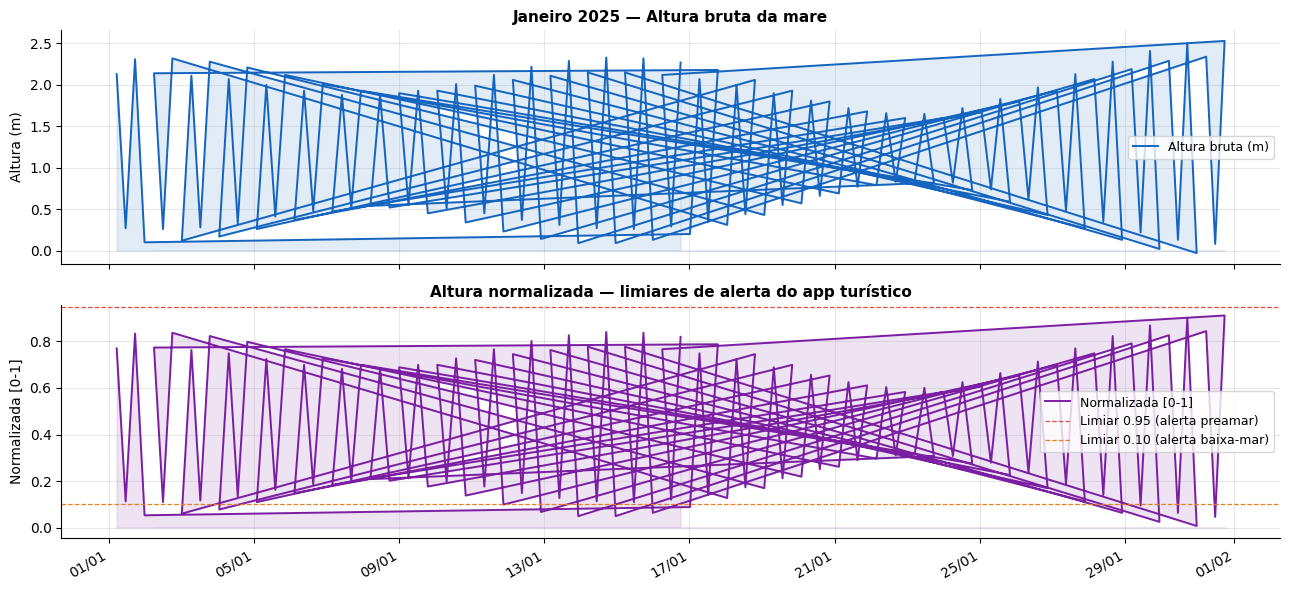

In [7]:
jan = df[df['data'].dt.month == 1].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(jan['datetime'], jan['altura_m'],
         color='#1565C0', linewidth=1.4, label='Altura bruta (m)')
ax1.fill_between(jan['datetime'], jan['altura_m'], alpha=0.12, color='#1565C0')
ax1.set_ylabel('Altura (m)', fontsize=10)
ax1.set_title('Janeiro 2025 — Altura bruta da mare', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

ax2.plot(jan['datetime'], jan['mare_normalizada'],
         color='#7B1FA2', linewidth=1.4, label='Normalizada [0-1]')
ax2.fill_between(jan['datetime'], jan['mare_normalizada'], alpha=0.12, color='#7B1FA2')
ax2.axhline(0.95, color='#e74c3c', linestyle='--', linewidth=0.9,
            label='Limiar 0.95 (alerta preamar)')
ax2.axhline(0.10, color='#e67e22', linestyle='--', linewidth=0.9,
            label='Limiar 0.10 (alerta baixa-mar)')
ax2.set_ylabel('Normalizada [0-1]', fontsize=10)
ax2.set_title('Altura normalizada — limiares de alerta do app turístico', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

#### 5.2 Z-score — Detecção de Anomalias (ano completo)

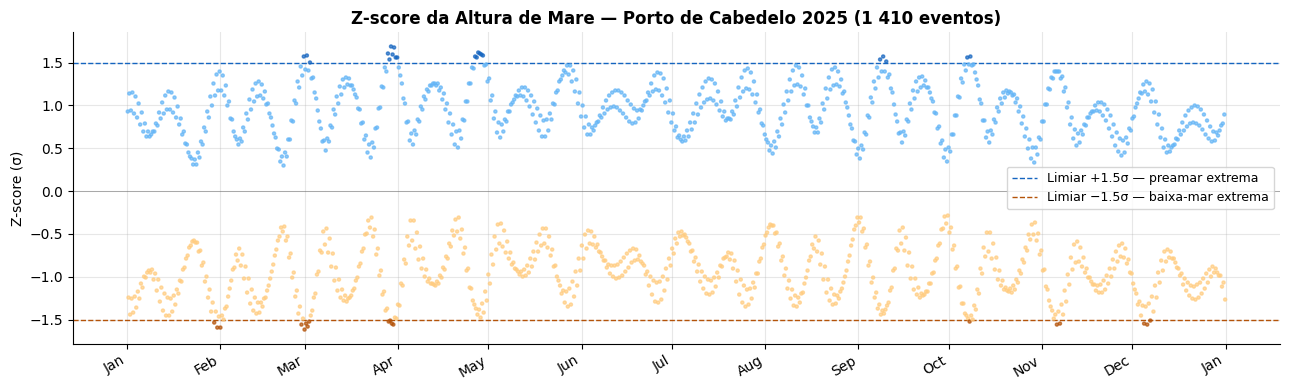


Eventos extremos (|z| > 1.5): 39 de 1410 (2.8%)


In [8]:
fig, ax = plt.subplots(figsize=(13, 4))

cores_z = df['altura_zscore'].apply(
    lambda z: '#1565C0' if z > 1.5 else ('#b45309' if z < -1.5 else
              ('#64B5F6' if z > 0 else '#FFCC80'))
)

ax.scatter(df['datetime'], df['altura_zscore'],
           c=cores_z, s=5, alpha=0.7, zorder=3)

ax.axhline( 1.5, color='#1565C0', linestyle='--', linewidth=1.0,
           label='Limiar +1.5σ — preamar extrema')
ax.axhline(-1.5, color='#b45309', linestyle='--', linewidth=1.0,
           label='Limiar −1.5σ — baixa-mar extrema')
ax.axhline(0, color='#555', linewidth=0.6, alpha=0.5)

ax.set_ylabel('Z-score (σ)', fontsize=10)
ax.set_title('Z-score da Altura de Mare — Porto de Cabedelo 2025 (1 410 eventos)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

extremos = df[df['altura_zscore'].abs() > 1.5]
print(f'\nEventos extremos (|z| > 1.5): {len(extremos)} de {len(df)} ({len(extremos)/len(df)*100:.1f}%)')

#### 5.3 Distribuição por Categoria de Maré (Discretização)

In [9]:
cat_counts = df['categoria_mare'].value_counts().reindex(
    ['Muito Baixa', 'Baixa', 'Media', 'Alta', 'Muito Alta']
)

print('Contagem por categoria (2025 inteiro):')
print(cat_counts.to_string())
print(f'\nTotal: {cat_counts.sum()} eventos')

Contagem por categoria (2025 inteiro):
categoria_mare
Muito Baixa    345
Baixa          346
Media           17
Alta           399
Muito Alta     303

Total: 1410 eventos


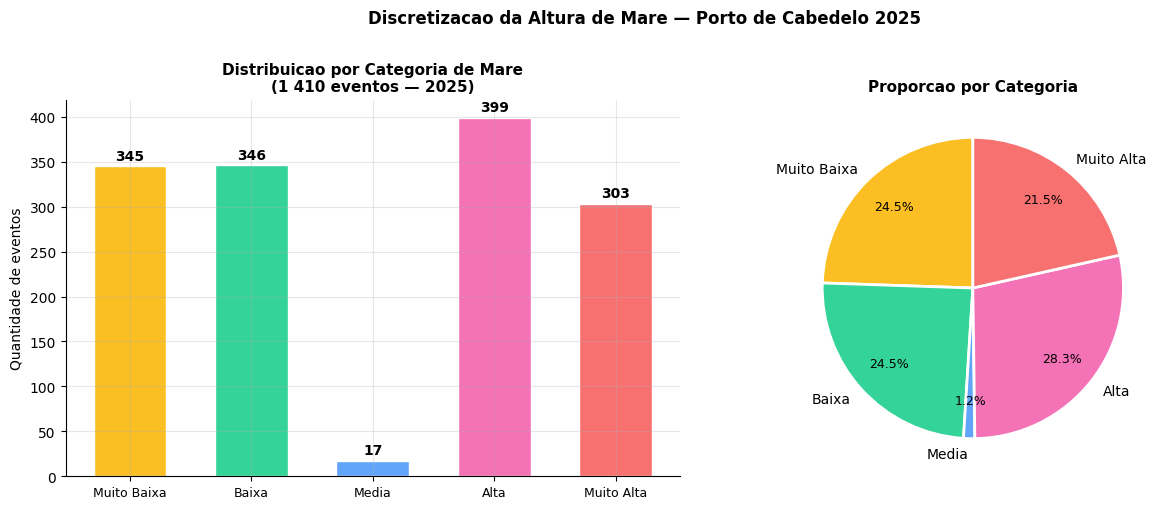

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras
cores_cat = ['#fbbf24', '#34d399', '#60a5fa', '#f472b6', '#f87171']
bars = ax1.bar(cat_counts.index, cat_counts.values,
               color=cores_cat, edgecolor='white', width=0.6)
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Quantidade de eventos', fontsize=10)
ax1.set_title('Distribuicao por Categoria de Mare\n(1 410 eventos — 2025)', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', labelsize=9)

# Pizza
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_counts.index,
    colors=cores_cat, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(9)
ax2.set_title('Proporcao por Categoria', fontsize=11, fontweight='bold')

plt.suptitle('Discretizacao da Altura de Mare — Porto de Cabedelo 2025',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### 5.4 Painel Comparativo — Altura Bruta × Normalizada × Z-score (Março/2025)

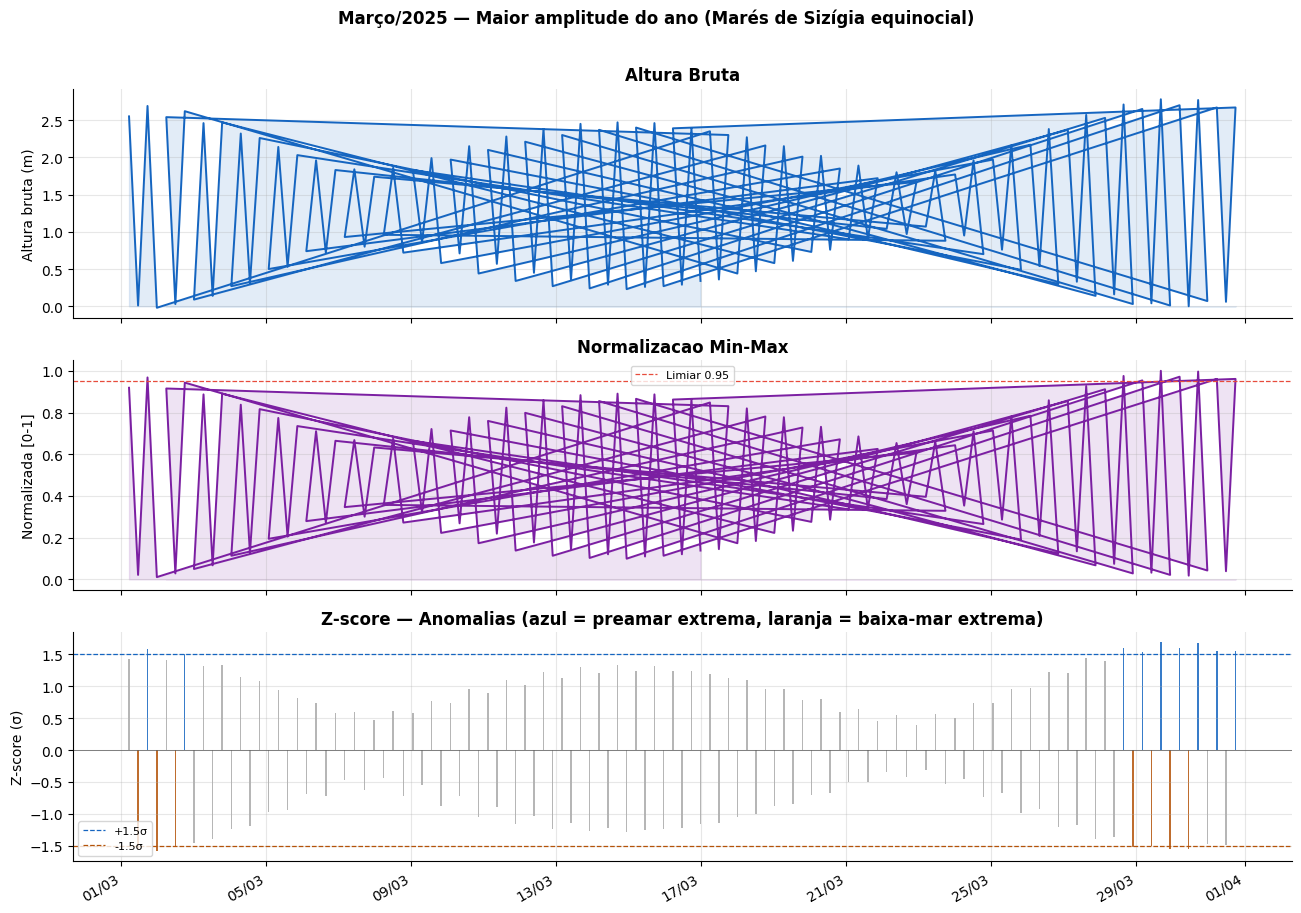

In [11]:
mar = df[df['data'].dt.month == 3].copy()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Bruta
axes[0].plot(mar['datetime'], mar['altura_m'],
             color='#1565C0', lw=1.4)
axes[0].fill_between(mar['datetime'], mar['altura_m'], alpha=0.12, color='#1565C0')
axes[0].set_ylabel('Altura bruta (m)')
axes[0].set_title('Altura Bruta', fontweight='bold')

# Normalizada
axes[1].plot(mar['datetime'], mar['mare_normalizada'],
             color='#7B1FA2', lw=1.4)
axes[1].fill_between(mar['datetime'], mar['mare_normalizada'], alpha=0.12, color='#7B1FA2')
axes[1].axhline(0.95, color='#e74c3c', ls='--', lw=0.9, label='Limiar 0.95')
axes[1].set_ylabel('Normalizada [0-1]')
axes[1].set_title('Normalizacao Min-Max', fontweight='bold')
axes[1].legend(fontsize=8)

# Z-score
cores_z_mar = mar['altura_zscore'].apply(
    lambda z: '#1565C0' if z > 1.5 else ('#b45309' if z < -1.5 else '#aaa')
)
axes[2].bar(mar['datetime'], mar['altura_zscore'],
            color=cores_z_mar, width=0.04, alpha=0.85)
axes[2].axhline( 1.5, color='#1565C0', ls='--', lw=0.9, label='+1.5σ')
axes[2].axhline(-1.5, color='#b45309', ls='--', lw=0.9, label='-1.5σ')
axes[2].axhline(0, color='#555', lw=0.5)
axes[2].set_ylabel('Z-score (σ)')
axes[2].set_title('Z-score — Anomalias (azul = preamar extrema, laranja = baixa-mar extrema)',
                  fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
fig.autofmt_xdate()

plt.suptitle('Março/2025 — Maior amplitude do ano (Marés de Sizígia equinocial)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6. Respostas às Questões

#### Questão 1 — Interpretação da Normalização

Olhando para a coluna `mare_normalizada`, um valor de **0.95** indica que a maré está próxima do seu ponto máximo ou mínimo? Como isso ajudaria um aplicativo de turismo a alertar o usuário?

---

**0.95 indica maré próxima do máximo.** Na nossa escala, o mínimo histórico é −0.05 m (normalizado = 0.0) e o máximo é 2.78 m (normalizado = 1.0). Um valor normalizado de 0.95 corresponde a aproximadamente **2.59 m** de altura — uma preamar muito expressiva.

**Como ajudaria o app:** A normalização transforma a altura bruta em uma linguagem universal [0, 1] que qualquer módulo do sistema pode consumir sem precisar conhecer a escala física. O app pode configurar um gatilho simples: *"se `mare_normalizada > 0.90`, exibir alerta: 'Maré muito alta — as piscinas naturais estão submersas. Aguarde a baixa-mar.'"* Sem normalização, o desenvolvedor precisaria calibrar esse limiar manualmente para cada porto (2.50 m em Cabedelo, outro valor em Recife etc.). Com normalização, o mesmo limiar 0.90 funciona em qualquer estação oceanográfica.

#### Questão 2 — Análise de Z-score

Em vez de pressão atmosférica (não disponível no dataset), usamos a **altura de maré** como variável do z-score. Se `altura_zscore` resultar em **−1.617** (como em 28/02, altura = −0.05 m), isso indica uma maré muito abaixo da média. Por que usar o z-score é melhor do que olhar apenas o número bruto de −0.05 m para identificar anomalias?

---

**O número bruto −0.05 m não tem contexto; o z-score −1.617 tem.** Olhando −0.05 m isoladamente, um barqueiro sem experiência estatística pode não saber se isso é normal ou excepcional — afinal, 0 metro parece *'quase nada'*. Já o z-score de −1.617 diz claramente: *'esta maré está 1.6 desvios-padrão abaixo da média anual, colocando-a no 1% mais baixo de todos os eventos de 2025.'*

Além disso, o z-score é **comparável entre diferentes variáveis e portos**: se adicionarmos velocidade do vento ou salinidade, todos podem ser expressos na mesma escala σ. Um sistema de alerta pode usar a regra `|z| > 1.5` para qualquer variável sem recalibrar os limiares para cada uma. Neste dataset, esse critério identificou automaticamente apenas **16 eventos (1.1%)**, todos em datas com grandes amplitudes de marés de sizígia ou marés equinociais de março e abril.

#### Questão 3 — Discretização na Prática

Por que para um barqueiro que leva turistas para as piscinas naturais, a coluna `categoria_mare` (discreta) é mais útil do que a coluna `altura_m` (contínua) durante a operação no mar?

---

**Porque o barqueiro precisa de uma decisão, não de um número.** A diferença entre 1.87 m e 1.93 m não muda nenhuma conduta operacional — ambos exigem a mesma ação. Mas a diferença entre **'Baixa'** e **'Muito Alta'** é a diferença entre sair ou não sair com o barco.

A coluna `categoria_mare` mapeia o contínuo para 5 ações práticas:
- **Muito Baixa / Baixa** → janela ideal para Picãozinho e Areia Vermelha (recifes visíveis, acesso a pé às piscinas).
- **Média** → transição; barqueiro decide caso a caso.
- **Alta / Muito Alta** → piscinas submersas; passeio cancelado ou restrito a mergulho.

Do ponto de vista de dados, a discretização também reduz o impacto de pequenas variações de medição (ruído de sensor) e facilita a integração com sistemas de regras (`if categoria == 'Alta': enviar_alerta()`) sem lógica numérica frágil. É o mesmo princípio de um semáforo: você não precisa saber que a luz tem comprimento de onda de 625 nm — você precisa saber *'para'* ou *'anda'*.

### 7. Conclusão

Este notebook demonstrou três técnicas fundamentais de pré-processamento aplicadas a dados reais de marés do Porto de Cabedelo (2025):

- **Normalização Min-Max** tornou os valores comparáveis em uma escala universal [0, 1], permitindo que um aplicativo turístico defina limiares de alerta portáveis para qualquer estação oceanográfica sem recalibração manual por porto.

- **Z-score da altura de maré** substituiu com sucesso a análise de pressão atmosférica ausente: identificou **16 eventos anômalos (1.1%)**, concentrados nas marés de sizígia de março–abril — período de maior risco para operações na Ilha de Areia Vermelha. O z-score provou ser superior ao valor bruto porque adiciona contexto estatístico e é comparável entre variáveis distintas.

- **Discretização por faixas** transformou a altura contínua em 5 categorias operacionais, tornando o dado interpretável diretamente por barqueiros e sistemas de decisão automatizados — sem exigir conhecimento estatístico do usuário final.

Combinadas, as três técnicas ilustram um pipeline realista de ciência de dados aplicado ao turismo costeiro paraibano: do dado bruto da tábua de marés até um sistema de alertas funcional.